In [1]:
#INFORMATIONEN ZUM DATENSATZ - TELCO CUSTOMER CHURN

#Der Telco-Datensatz enthält Informationen über ein fiktives Telekommunikationsunternehmen, das im dritten Quartal 7043 Kunden in Kalifornien mit Festnetz- und Internetdiensten versorgt hat.
#Der Datensatz gibt Auskunft darüber, welche Kunden ihren Dienst gekündigt haben ("Churn"), welche geblieben sind oder neu hinzugekommen sind. Jede Zeile repräsentiert einen einzelnen Kunden.
 
#CustomerId: Eine eindeutige Kennung für jeden Kunden.
#Gender: Das Geschlecht des Kunden.
#SeniorCitizen: Gibt an, ob der Kunde ein Senior ist (1: ja, 0: nein).
#Partner: Gibt an, ob der Kunde einen Partner (Ehepartner) hat (Ja, Nein).
#Dependents: Zeigt, ob der Kunde unterhaltsberechtigte Personen wie Kinder oder ältere Familienangehörige hat (Ja, Nein).
#tenure: Die Anzahl der Monate, die der Kunde beim Unternehmen geblieben ist.
#PhoneService: Gibt an, ob der Kunde einen Telefonservice nutzt (Ja, Nein).
#MultipleLines: Gibt an, ob der Kunde mehrere Telefonleitungen hat (Ja, Nein, Kein Telefonservice).
#InternetService: Der Internetanbieter des Kunden (DSL, Glasfaser, Kein Internetdienst).
#OnlineSecurity: Gibt an, ob der Kunde einen Online-Sicherheitsdienst nutzt (Ja, Nein, Kein Internetdienst).
#OnlineBackup: Gibt an, ob der Kunde ein Online-Backup nutzt (Ja, Nein, Kein Internetdienst).
#DeviceProtection: Gibt an, ob der Kunde einen Geräteschutzdienst nutzt (Ja, Nein, Kein Internetdienst).
#TechSupport: Gibt an, ob der Kunde technischen Support in Anspruch nimmt (Ja, Nein, Kein Internetdienst).
#StreamingTV: Zeigt, ob der Kunde seinen Internetdienst zum Streamen von Fernsehinhalten über Drittanbieter verwendet.
#StreamingMovies: Zeigt, ob der Kunde seinen Internetdienst zum Streamen von Filmen über Drittanbieter verwendet.
#Contract: Die Vertragslaufzeit des Kunden (Monatlich, Ein Jahr, Zwei Jahre).
#PaperlessBilling: Gibt an, ob der Kunde papierlose Rechnungen nutzt (Ja, Nein).
#PaymentMethod: Die Zahlungsmethode des Kunden (Elektronischer Scheck, Post-Scheck, Banküberweisung (automatisch), Kreditkarte (automatisch)).
#MonthlyCharges: Der monatlich vom Kunden berechnete Betrag.
#TotalCharges: Der insgesamt vom Kunden berechnete Betrag.
#Churn: Gibt an, ob der Kunde den Dienst im letzten Monat oder Quartal gekündigt hat (Ja oder Nein).

#Jede Zeile repräsentiert einen einzelnen, einzigartigen Kunden.
#Die Variablen enthalten Informationen zu den Bereichen Kundendienst, Kontoinformationen und demografische Merkmale:

#Kundendienste: Informationen zu abonnierten Diensten wie Telefon, Mehrfachleitungen, Internet, Online-Sicherheit, Online-Backup, Geräteschutz, technischer Support sowie Streaming von TV und Filmen.
#Kontoinformationen: Angaben darüber, wie lange der Kunde Kunde ist, Vertragsart, Zahlungsmethode, papierlose Abrechnung sowie monatliche und gesamte Gebühren.
#Demografische Informationen: Geschlecht, Altersgruppe sowie ob Partner oder unterhaltsberechtigte Personen vorhanden sind.

In [2]:
#DATAENVORBEREITUNG

In [3]:
# Erforderliche Bibliotheken importieren
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#!pip install missingno
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [4]:
#Datensatz laden und erste Einblicke erhalten
TelcoChurn = pd.read_csv("C:/Users/nesri/Downloads/Telco-Customer-Churn.csv")
df = TelcoChurn.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [5]:
#Allgemeine Informationen zum Datensatz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.duplicated().sum()

0

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750


In [8]:
#Analyse von kategorialen und numerischen Variablen

def grab_col_names(dataframe, cat_th=10, car_th=20):
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category","object","bool"]]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes in ["uint8","int64","float64"]]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and str(dataframe[col].dtypes) in ["category","object"]]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["uint8","int64","float64"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    return cat_cols, num_cols, cat_but_car, num_but_cat

cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(df)

print(f"Observations: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print(f"Cat_cols: {len(cat_cols)}")
print(f"Num_cols: {len(num_cols)}")
print(f"Cat_but_car: {len(cat_but_car)}")
print(f"num_but_cat: {len(  num_but_cat)}")

Observations: 7043
Variables: 21
Cat_cols: 17
Num_cols: 2
Cat_but_car: 2
num_but_cat: 1


In [9]:
# TotalCharges sollte eine numerische Variable sein.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
# SeniorCitizen sollte eine kategoriale Variable sein.
df["SeniorCitizen"] = df["SeniorCitizen"].astype("object")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


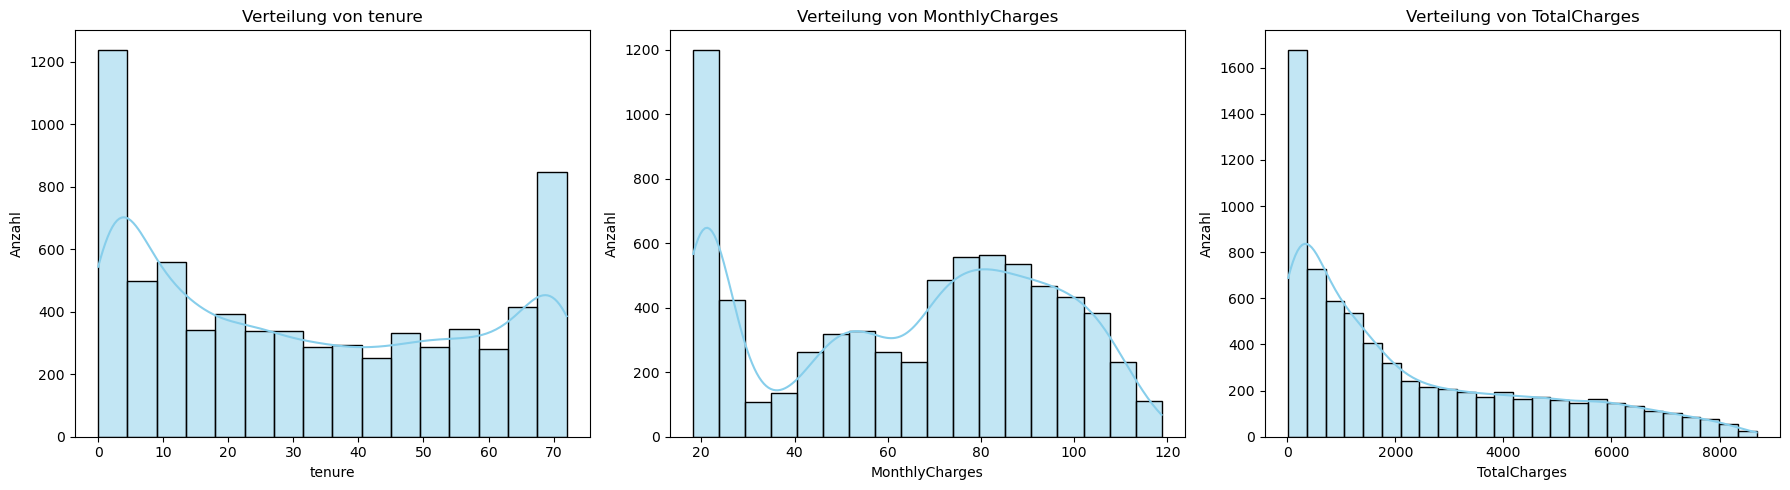

In [11]:
# Numerische Variablen visualisieren
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 5))  

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(f"Verteilung von {col}") 
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Anzahl")  

plt.tight_layout()
plt.show()

In [12]:
## Verteilung der Zielvariable
df["Churn"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0) 
def target_summary_with_cat(dataframe, target, categorical_col):
    print(categorical_col)
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean().sort_values(ascending=False),
                        "COUNT": dataframe[categorical_col].value_counts(),
                        "RATIO": 100 * dataframe[categorical_col].value_counts() / len(dataframe)}), end="\n\n\n")

for col in cat_cols:
    target_summary_with_cat(df, "Churn", col)

gender
        TARGET_MEAN  COUNT  RATIO
gender                           
Female        0.269   3488 49.524
Male          0.262   3555 50.476


Partner
         TARGET_MEAN  COUNT  RATIO
Partner                           
No             0.330   3641 51.697
Yes            0.197   3402 48.303


Dependents
            TARGET_MEAN  COUNT  RATIO
Dependents                           
No                0.313   4933 70.041
Yes               0.155   2110 29.959


PhoneService
              TARGET_MEAN  COUNT  RATIO
PhoneService                           
Yes                 0.267   6361 90.317
No                  0.249    682  9.683


MultipleLines
                  TARGET_MEAN  COUNT  RATIO
MultipleLines                              
No                      0.250   3390 48.133
No phone service        0.249    682  9.683
Yes                     0.286   2971 42.184


InternetService
                 TARGET_MEAN  COUNT  RATIO
InternetService                           
Fiber optic            0.41

In [13]:
#Fehlende Werte analysieren
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
def missing_values_table(dataframe, na_name=False):

    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (100 * dataframe[na_columns].isnull().sum() / len(dataframe)).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=["n_miss", "ratio"])
    print(missing_df, end="\n\n")

    if na_name:
        return na_columns
na_columns = missing_values_table(df, True)

              n_miss  ratio
TotalCharges      11  0.160



In [15]:
missing_indexes = df[df["TotalCharges"].isnull()].index
missing_indexes

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [16]:
df.loc[missing_indexes, "TotalCharges"]

488    NaN
753    NaN
936    NaN
1082   NaN
1340   NaN
3331   NaN
3826   NaN
4380   NaN
5218   NaN
6670   NaN
6754   NaN
Name: TotalCharges, dtype: float64

In [17]:
# Wenn tenure = 0, dann wird TotalCharges als 0 angenommen.
df.loc[(df["TotalCharges"].isnull()) & (df["tenure"] == 0), "TotalCharges"] = 0

# Wenn weitere fehlende Werte vorhanden sind, fülle sie mit MonthlyCharges × tenure aus.
df["TotalCharges"] = df.apply(
    lambda row: row["MonthlyCharges"] * row["tenure"] if pd.isnull(row["TotalCharges"]) else row["TotalCharges"], 
    axis=1
)

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
# Ausreißer-Werte 
# Ausreißer-Werte pro numerischer Spalte
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    if not outliers.empty:
        print(f"Ausreißer in der Spalte '{col}':")
        print(f"Anzahl der Ausreißer: {len(outliers)}")
        print(f"Werte: {outliers.tolist()}\n")
    else:
        print(f"Keine Ausreißer in der Spalte '{col}'.\n")


Keine Ausreißer in der Spalte 'tenure'.

Keine Ausreißer in der Spalte 'MonthlyCharges'.

Keine Ausreißer in der Spalte 'TotalCharges'.

Keine Ausreißer in der Spalte 'Churn'.



In [20]:
df[numeric_cols].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


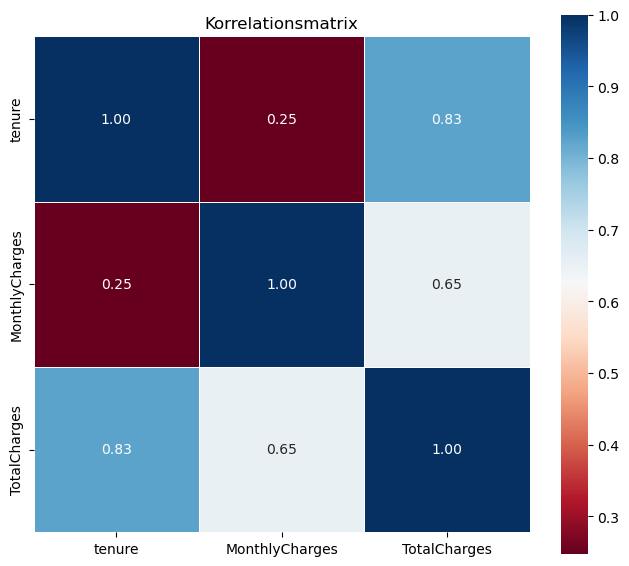

In [21]:
# Korrelationsmatrix als Heatmap darstellen 
plt.figure(figsize=(8, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="RdBu", square=True, linewidths=0.7)
plt.title("Korrelationsmatrix", fontsize=12)
plt.show()

In [22]:
# NEUE MERKMALE ERSTELLEN

In [23]:
#Erstellung der Kundenbindungsdauer-Kategorie (TenureGroup)
df['TenureGroup'] = pd.cut( df['tenure'],  bins=[0, 12, 24, 48, 60, 72], labels=['0-12m', '12-24m', '24-48m', '48-60m', '60-72m'])
df["TenureGroup"].value_counts()

TenureGroup
0-12m     2175
24-48m    1594
60-72m    1407
12-24m    1024
48-60m     832
Name: count, dtype: int64

In [24]:
df.groupby("TenureGroup", observed=True)["Churn"]\
                .value_counts(normalize=True)\
                .mul(100)\
                .rename("ChurnRate")

TenureGroup  Churn
0-12m        0       52.322
             1       47.678
12-24m       0       71.289
             1       28.711
24-48m       0       79.611
             1       20.389
48-60m       0       85.577
             1       14.423
60-72m       0       93.390
             1        6.610
Name: ChurnRate, dtype: float64

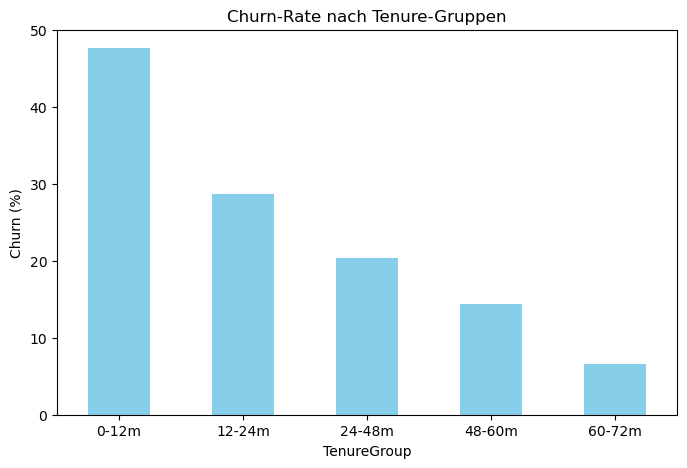

In [25]:
churn_by_TenureGroup = df.groupby("TenureGroup", observed=True)["Churn"].mean() * 100
churn_by_TenureGroup.plot(
    kind="bar",
    legend=False,
    ylabel="Churn (%)",
    title="Churn-Rate nach Tenure-Gruppen",
    figsize=(8, 5),
    color="skyblue"
)
plt.xticks(rotation=0)
plt.show()

In [26]:
#Zwischen der Verweildauer des Kunden im Unternehmen (tenure) und der Kündigung (Churn) besteht in der Regel eine sehr starke Beziehung.
#Bei Kunden mit langer Verweildauer im Unternehmen ist die Wahrscheinlichkeit einer Kündigung geringer.

In [27]:
#Erstellung der Internetnutzungs-Kategorie (InternetUser)
#Neue Variable 'InternetUser' erstellen, die angibt, ob ein Kunde Internetdienst hat oder nicht
df["InternetUser"] = df["InternetService"].apply(lambda x: "Yes" if x in ["DSL", "Fiber optic"] else "No")
df["InternetUser"].value_counts()

InternetUser
Yes    5517
No     1526
Name: count, dtype: int64

In [28]:
df.groupby("InternetUser", observed=True)["Churn"]\
                .value_counts(normalize=True)\
                .mul(100)\
                .rename("ChurnRate")

InternetUser  Churn
No            0       92.595
              1        7.405
Yes           0       68.171
              1       31.829
Name: ChurnRate, dtype: float64

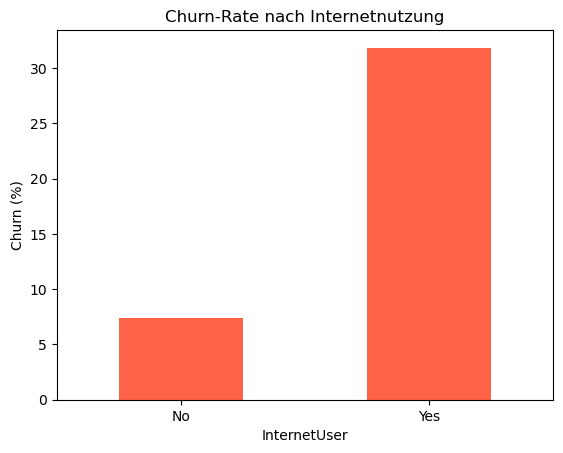

In [29]:
churn_by_InternetUser = df.groupby("InternetUser", observed=True)["Churn"].mean() * 100
churn_by_InternetUser.plot(kind='bar', color='tomato', title='Churn-Rate nach Internetnutzung', ylabel='Churn (%)')
plt.xticks(rotation=0)
plt.show()

In [30]:
#Die Kündigungsrate ist bei Kunden, die einen Internetdienst nutzen, höher.

In [31]:
#Erstellung der Gesamtanzahl der genutzten Services (NumServices)

#Standardisierung der Serviceangaben
Service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'InternetUser']
#Ersetze die Ausdrücke 'No internet service' und 'No phone service' durch 'No'.
df[Service_cols] = df[Service_cols].replace({
    'No internet service': 'No',
    'No phone service': 'No'})
df["NumServices"] = df[Service_cols].apply(lambda row: sum(row == "Yes"), axis=1)
df["NumServices"].value_counts()

NumServices
1    1264
4     965
5     922
6     908
2     859
3     846
7     676
8     395
9     208
Name: count, dtype: int64

In [32]:
churn_by_NumServices = df.groupby("NumServices", observed=True)["Churn"]\
                .value_counts(normalize=True)\
                .mul(100)\
                .rename("ChurnRate")\
                .reset_index()

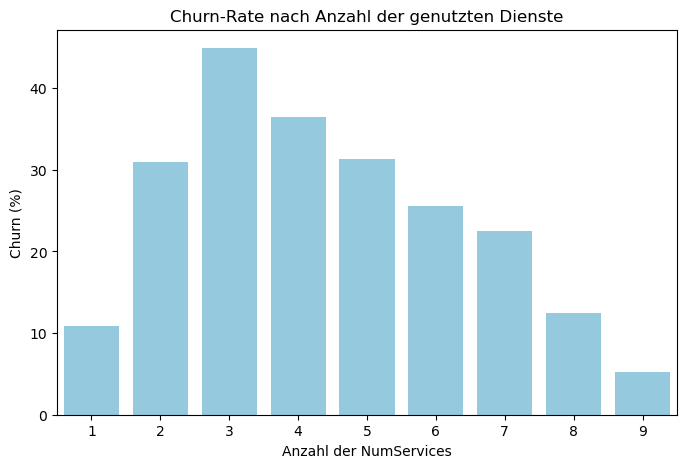

In [33]:
#Nur die Zeilen mit Churn=1 (Kündigung) auswählen
churn_1_by_NumServices = churn_by_NumServices[churn_by_NumServices["Churn"] == 1]

plt.figure(figsize=(8,5))
sns.barplot(data=churn_1_by_NumServices , x="NumServices", y="ChurnRate", color="skyblue")
plt.title("Churn-Rate nach Anzahl der genutzten Dienste")
plt.ylabel("Churn (%)")
plt.xlabel("Anzahl der NumServices")
plt.show()

In [34]:
#Je mehr Dienste ein Kunde nutzt, desto geringer ist die Wahrscheinlichkeit, dass er kündigt.
#Kunden, die mehr Dienste nutzen, sind in der Regel loyaler, und das Kündigungsrisiko ist niedriger. 
#Mit zunehmender Anzahl der genutzten Dienste kann die Kundenbindung steigen, jedoch ist das Kündigungsrisiko bei Nutzern mit mittlerer Dienstanzahl höher.
#Deshalb ist es sinnvoll, die Gründe für die Kündigung von Kunden mit 3-4 genutzten Diensten zu analysieren und spezielle Strategien zur Steigerung der Kundenzufriedenheit zu entwickeln.

In [35]:
#Erstellung der Langzeitvertrags-Kategorie (IsLongTermContract)
# IsLongTermContract zeigt an, ob der Kunde einen längerfristigen Vertrag hat (ein- oder zwei Jahre).
df["IsLongTermContract"] = df["Contract"].isin(["One year", "Two year"]).astype(int)
df["IsLongTermContract"].value_counts()

IsLongTermContract
0    3875
1    3168
Name: count, dtype: int64

In [36]:
df.groupby("IsLongTermContract", observed=True)["Churn"]\
                .value_counts(normalize=True)\
                .mul(100)\
                .rename("ChurnRate")

IsLongTermContract  Churn
0                   0       57.290
                    1       42.710
1                   0       93.245
                    1        6.755
Name: ChurnRate, dtype: float64

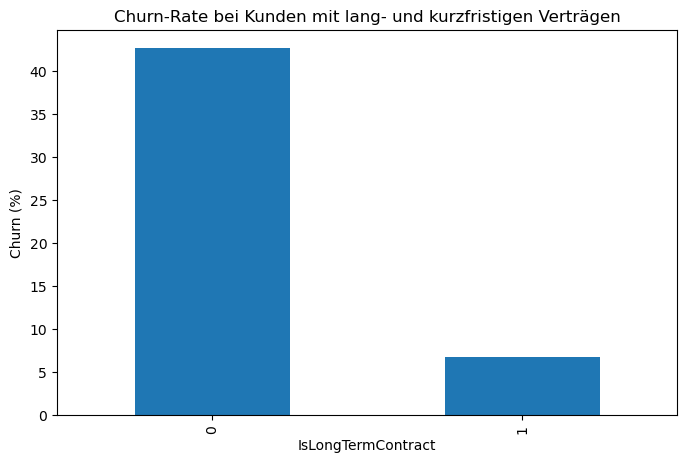

In [37]:
churn_by_Contract = df.groupby("IsLongTermContract")["Churn"].mean() * 100

churn_by_Contract.plot(kind="bar", legend=False, ylabel="Churn (%)", title="Churn-Rate bei Kunden mit lang- und kurzfristigen Verträgen", figsize=(8, 5))
plt.show()

In [38]:
#Der Besitz eines langfristigen Vertrags reduziert das Risiko einer Kündigung des Abonnements deutlich.

In [39]:
#Erstellung der Automatische Zahlungsmethode Kategorie (IsAutoPay)
#IsAutoPay zeigt an, ob die Zahlungsmethode des Kunden automatisch ist. Wenn die Zahlungsmethode automatisch ist 
#(z. B. automatische Überweisung oder automatische Kreditkartenzahlung), erhält sie den Wert 1, andernfalls 0.
df["IsAutoPay"] = df["PaymentMethod"].str.contains("automatic", case=False).astype(int)
df["IsAutoPay"].value_counts()

IsAutoPay
0    3977
1    3066
Name: count, dtype: int64

In [40]:
df.groupby("IsAutoPay", observed=True)["Churn"]\
                .value_counts(normalize=True)\
                .mul(100)\
                .rename("ChurnRate")

IsAutoPay  Churn
0          0       65.326
           1       34.674
1          0       84.018
           1       15.982
Name: ChurnRate, dtype: float64

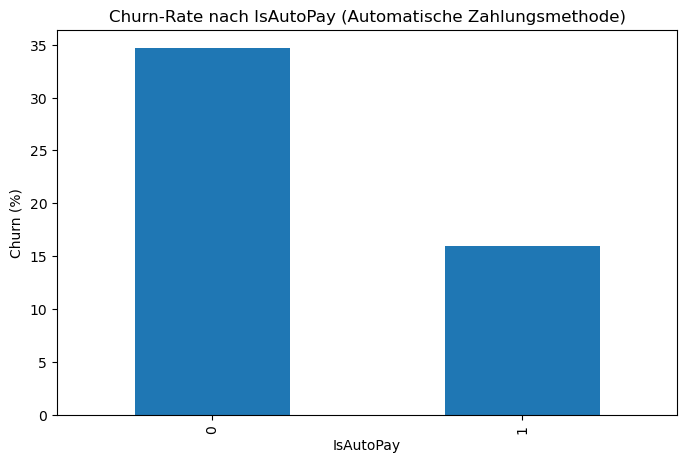

In [41]:
churn_by_IsAutoPay = df.groupby("IsAutoPay")["Churn"].mean() * 100

churn_by_IsAutoPay.plot(kind="bar", legend=False, ylabel="Churn (%)", title="Churn-Rate nach IsAutoPay (Automatische Zahlungsmethode)", figsize=(8, 5))
plt.show()

In [42]:
#Kunden, die die automatische Zahlungsoption nutzen, haben eine deutlich niedrigere Kündigungsrate im Vergleich zu denen, die keine automatische Zahlung verwenden

In [43]:
#MODELLIERUNG 

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customerID          7043 non-null   object  
 1   gender              7043 non-null   object  
 2   SeniorCitizen       7043 non-null   object  
 3   Partner             7043 non-null   object  
 4   Dependents          7043 non-null   object  
 5   tenure              7043 non-null   int64   
 6   PhoneService        7043 non-null   object  
 7   MultipleLines       7043 non-null   object  
 8   InternetService     7043 non-null   object  
 9   OnlineSecurity      7043 non-null   object  
 10  OnlineBackup        7043 non-null   object  
 11  DeviceProtection    7043 non-null   object  
 12  TechSupport         7043 non-null   object  
 13  StreamingTV         7043 non-null   object  
 14  StreamingMovies     7043 non-null   object  
 15  Contract            7043 non-null   ob

In [45]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

excluded_cols = ["customerID"]

# Erstellen einer Kopie des DataFrames für die Kodierung
df_encoded = df.copy()

# Auswahl der binären kategorialen Variablen (mit genau 2 Ausprägungen), außer 'customerID'
binary_cols = [
    col for col in df_encoded.columns 
    if df_encoded[col].dtype == "object" and 
       df_encoded[col].nunique() == 2 and 
       col not in excluded_cols
]

# Label-Encoding der binären kategorialen Variablen
label_encoder = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# Auswahl der kategorialen Variablen mit mehr als 2 Ausprägungen für One-Hot-Encoding
one_hot_cols = [
    col for col in df_encoded.columns 
    if df_encoded[col].dtype == "object" and 
       df_encoded[col].nunique() > 2 and 
       col not in excluded_cols
]

# One-Hot-Encoder mit drop='first', um Dummy-Variablen-Falle zu vermeiden
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = ohe.fit_transform(df_encoded[one_hot_cols])

# Erzeugen der neuen Spaltennamen für One-Hot-kodierte Variablen
encoded_cols = ohe.get_feature_names_out(one_hot_cols)

# Erstellen eines DataFrames mit den One-Hot-kodierten Variablen
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df_encoded.index)

# Entfernen der ursprünglichen kategorialen Spalten
df_encoded.drop(columns=one_hot_cols, inplace=True)

# Hinzufügen der One-Hot-kodierten Spalten zum DataFrame
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)


In [46]:
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TenureGroup,InternetUser,NumServices,IsLongTermContract,IsAutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.850,29.850,0,0-12m,1,2,0,0,0.000,0.000,0.000,0.000,0.000,1.000,0.000
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.950,1889.500,0,24-48m,1,4,1,0,0.000,0.000,1.000,0.000,0.000,0.000,1.000
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.850,108.150,1,0-12m,1,4,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1.000
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.300,1840.750,0,24-48m,1,4,1,1,0.000,0.000,1.000,0.000,0.000,0.000,0.000
4,9237-HQITU,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.700,151.650,1,0-12m,1,2,0,0,1.000,0.000,0.000,0.000,0.000,1.000,0.000


In [47]:
# Standardisierung numerischer Variablen
from sklearn.preprocessing import StandardScaler

# StandardScaler-Objekt erstellen
scaler = StandardScaler()

# Liste der numerischen Spalten definieren
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Numerische Variablen standardisieren (Mittelwert=0, Standardabweichung=1)
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [48]:
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TenureGroup,InternetUser,NumServices,IsLongTermContract,IsAutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,-1.277,0,0,0,1,0,0,0,0,1,-1.160,-0.993,0,0-12m,1,2,0,0,0.000,0.000,0.000,0.000,0.000,1.000,0.000
1,5575-GNVDE,1,0,0,0,0.066,1,0,1,0,1,0,0,0,0,-0.260,-0.172,0,24-48m,1,4,1,0,0.000,0.000,1.000,0.000,0.000,0.000,1.000
2,3668-QPYBK,1,0,0,0,-1.237,1,0,1,1,0,0,0,0,1,-0.363,-0.958,1,0-12m,1,4,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1.000
3,7795-CFOCW,1,0,0,0,0.514,0,0,1,0,1,1,0,0,0,-0.747,-0.194,0,24-48m,1,4,1,1,0.000,0.000,1.000,0.000,0.000,0.000,0.000
4,9237-HQITU,0,0,0,0,-1.237,1,0,0,0,0,0,0,0,1,0.197,-0.939,1,0-12m,1,2,0,0,1.000,0.000,0.000,0.000,0.000,1.000,0.000


In [49]:
from sklearn.preprocessing import OneHotEncoder

one_hot_cols = ["TenureGroup"]

ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded_array = ohe.fit_transform(df_encoded[one_hot_cols])
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(one_hot_cols), index=df_encoded.index)

df_encoded.drop(columns=one_hot_cols, inplace=True)
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)

In [50]:
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetUser,NumServices,IsLongTermContract,IsAutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24m,TenureGroup_24-48m,TenureGroup_48-60m,TenureGroup_60-72m,TenureGroup_nan
0,7590-VHVEG,0,0,1,0,-1.277,0,0,0,1,0,0,0,0,1,-1.160,-0.993,0,1,2,0,0,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
1,5575-GNVDE,1,0,0,0,0.066,1,0,1,0,1,0,0,0,0,-0.260,-0.172,0,1,4,1,0,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000
2,3668-QPYBK,1,0,0,0,-1.237,1,0,1,1,0,0,0,0,1,-0.363,-0.958,1,1,4,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
3,7795-CFOCW,1,0,0,0,0.514,0,0,1,0,1,1,0,0,0,-0.747,-0.194,0,1,4,1,1,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
4,9237-HQITU,0,0,0,0,-1.237,1,0,0,0,0,0,0,0,1,0.197,-0.939,1,1,2,0,0,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000


In [51]:
#Random Forest Modellierung zur Kundenabwanderungsvorhersage
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Zielvariable und Merkmale
y = df_encoded["Churn"]
X = df_encoded.drop(["Churn", "customerID"], axis=1)

# Trainings- und Testdatensatz aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# Random Forest Modell erstellen und trainieren
rf_model = RandomForestClassifier(random_state=46)
rf_model.fit(X_train, y_train)

# Vorhersage
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # <--- AUC için önemli

# Modellbewertung
print(f"Genauigkeit (Accuracy): {round(accuracy_score(y_test, y_pred), 2)}")
print(f"Trefferquote (Recall): {round(recall_score(y_test, y_pred), 2)}")
print(f"Präzision (Precision): {round(precision_score(y_test, y_pred), 2)}")
print(f"F1-Score: {round(f1_score(y_test, y_pred), 2)}")
print(f"AUC: {round(roc_auc_score(y_test, y_proba), 2)}")

Genauigkeit (Accuracy): 0.78
Trefferquote (Recall): 0.47
Präzision (Precision): 0.63
F1-Score: 0.54
AUC: 0.81


In [52]:
#XGBoost Modellierung zur Kundenabwanderungsvorhersage
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Zielvariable (abhängige Variable)
y = df_encoded["Churn"]

# Merkmale (unabhängige Variablen)
X = df_encoded.drop(["Churn", "customerID"], axis=1)

# Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# XGBoost-Modell erstellen und trainieren
xgb_model = XGBClassifier(random_state=46)
xgb_model.fit(X_train, y_train)

# Vorhersage auf Testdaten
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Modellbewertung
print(f"Genauigkeit (Accuracy): {round(accuracy_score(y_test, y_pred), 2)}")
print(f"Trefferquote (Recall): {round(recall_score(y_test, y_pred), 2)}")
print(f"Präzision (Precision): {round(precision_score(y_test, y_pred), 2)}")
print(f"F1-Score: {round(f1_score(y_test, y_pred), 2)}")
print(f"AUC: {round(roc_auc_score(y_test, y_proba), 2)}")

Genauigkeit (Accuracy): 0.77
Trefferquote (Recall): 0.49
Präzision (Precision): 0.6
F1-Score: 0.54
AUC: 0.81


In [53]:
#K-Nearest Neighbors (KNN) Modellierung zur Kundenabwanderungsvorhersage
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Zielvariable und Merkmale definieren
y = df_encoded["Churn"]
X = df_encoded.drop(["Churn", "customerID"], axis=1)

# Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# KNN-Modell erstellen (k=5 standardmäßig)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Vorhersagen auf Testdaten machen
y_pred = knn_model.predict(X_test)

# Modellbewertung
print(f"Genauigkeit (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print(f"Trefferquote (Recall): {recall_score(y_test, y_pred):.2f}")
print(f"Präzision (Precision): {precision_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")

# AUC mit predict_proba berechnen
y_proba = knn_model.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, y_proba):.2f}")

Genauigkeit (Accuracy): 0.75
Trefferquote (Recall): 0.52
Präzision (Precision): 0.55
F1-Score: 0.53
AUC: 0.77


In [54]:
# CatBoost Modellierung zur Kundenabwanderungsvorhersage
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Zielvariable und Merkmale definieren
y = df_encoded["Churn"]
X = df_encoded.drop(["Churn", "customerID"], axis=1)

# Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# CatBoost-Modell erstellen und trainieren
catboost_model = CatBoostClassifier(verbose=False, random_state=46)
catboost_model.fit(X_train, y_train)

# Vorhersagen auf Testdaten machen
y_pred = catboost_model.predict(X_test)

# Modellbewertung
print(f"Genauigkeit (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print(f"Trefferquote (Recall): {recall_score(y_test, y_pred):.2f}")
print(f"Präzision (Precision): {precision_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")

# AUC mit predict_proba berechnen
y_proba = catboost_model.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, y_proba):.2f}")

Genauigkeit (Accuracy): 0.79
Trefferquote (Recall): 0.50
Präzision (Precision): 0.64
F1-Score: 0.56
AUC: 0.82


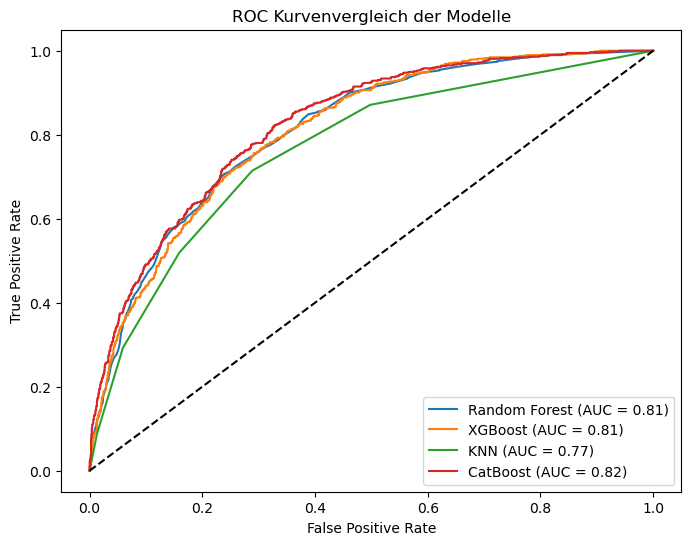

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Modellvorhersagewahrscheinlichkeiten erhalten
y_scores_rf = rf_model.predict_proba(X_test)[:,1]
y_scores_xgb = xgb_model.predict_proba(X_test)[:,1]
y_scores_knn = knn_model.predict_proba(X_test)[:,1]
y_scores_cat = catboost_model.predict_proba(X_test)[:,1]  

# Berechnung der ROC-Werte
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_scores_xgb)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_scores_knn)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_scores_cat)  

# Berechnung der AUC-Werte
auc_rf = roc_auc_score(y_test, y_scores_rf)
auc_xgb = roc_auc_score(y_test, y_scores_xgb)
auc_knn = roc_auc_score(y_test, y_scores_knn)
auc_cat = roc_auc_score(y_test, y_scores_cat)  

# Erstellung der Grafiken
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.2f})')

plt.plot([0,1], [0,1], 'k--')  # 45 Grad Diagonale
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurvenvergleich der Modelle')
plt.legend(loc='lower right')
plt.show()


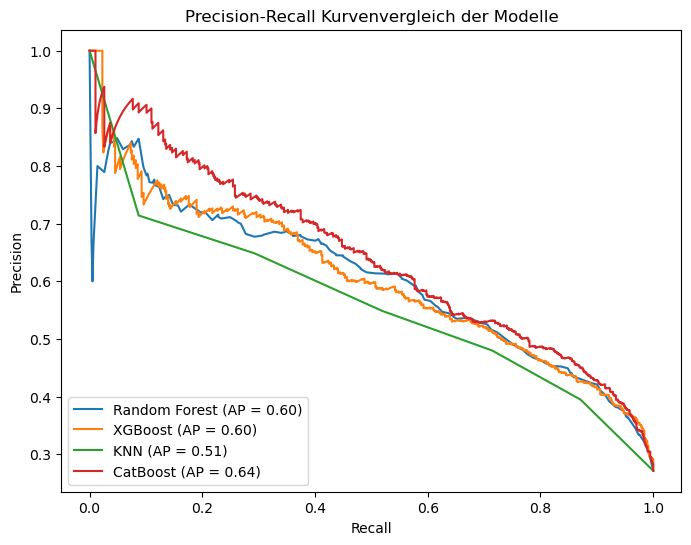

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Wahrscheinlichkeiten der Modelle vorhersagen
y_scores_rf = rf_model.predict_proba(X_test)[:,1]
y_scores_xgb = xgb_model.predict_proba(X_test)[:,1]
y_scores_knn = knn_model.predict_proba(X_test)[:,1]
y_scores_cat = catboost_model.predict_proba(X_test)[:,1]  

# Precision- und Recall-Werte berechnen
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_scores_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_scores_xgb)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_scores_knn)
precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_scores_cat)  

# Average Precision (AP) berechnen
ap_rf = average_precision_score(y_test, y_scores_rf)
ap_xgb = average_precision_score(y_test, y_scores_xgb)
ap_knn = average_precision_score(y_test, y_scores_knn)
ap_cat = average_precision_score(y_test, y_scores_cat)  

# Erstellung der Grafiken
plt.figure(figsize=(8,6))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.2f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {ap_xgb:.2f})')
plt.plot(recall_knn, precision_knn, label=f'KNN (AP = {ap_knn:.2f})')
plt.plot(recall_cat, precision_cat, label=f'CatBoost (AP = {ap_cat:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Kurvenvergleich der Modelle')
plt.legend(loc='lower left')
plt.show()
